## Using edgeR for DEG analysis between regions -- comparing region_leiden clusters within capillary cells and using pseurod-bulk approach

In [1]:
### identify cluster marker genes
suppressPackageStartupMessages({
    library(Seurat)
    library(stringr)
    library(dplyr)
    library(patchwork)
    library(ggplot2)
    library(ggrepel)
    library(future)
    library(tidydr)
    library(harmony)
    library(reticulate)
    library(viridis)
    library(RColorBrewer)
    library(ComplexHeatmap)
    library(colorRamp2)
    library(edgeR)
    library(DESeq2)
})

# set large memory  
options(future.globals.maxSize = 120*1024^3)

## plotting parameters
umap_theme <- theme_dr()+theme(panel.grid.major = element_blank(), 
                                            panel.grid.minor = element_blank(),
                                            panel.background = element_blank(), 
                                            axis.line = element_line(colour = "black"))

## set working dir
dir = "/home/kibr/Work/Vascular_atlas"
setwd(dir)

In [2]:
## Reloading 
# Convert h5ad to h5seurat
h5ad_file="./Results/Revision_2/clean_object_revision_04242026.h5ad"
obj_oi = schard::h5ad2seurat(h5ad_file)

obj_oi = subset(obj_oi, subset = Cell_type == "Capillary")
print(obj_oi)

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.decontx_ to Xumapdecontx_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony_ to Xumapharmony_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony.denoised_ to Xumapharmonydenoised_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.rna_ to Xumaprna_”


An object of class Seurat 
36782 features across 26486 samples within 1 assay 
Active assay: RNA (36782 features, 0 variable features)
 2 layers present: counts, data
 8 dimensional reductions calculated: Xharmony_, Xpca_, Xpcaharmony_, Xumap.decontx_, Xumap.harmony_, Xumap.harmony.denoised_, Xumap.rna_, umapharmony_


In [6]:
## exclude samples with less than 3 cells
meta = obj_oi@meta.data
mat = table(meta$region_name)
sample_excluded = names(mat[mat<100])
length(sample_excluded)

obj_oi = subset(obj_oi,subset = !region_name %in% sample_excluded)
obj_oi

[1] 0

An object of class Seurat 
36782 features across 26301 samples within 1 assay 
Active assay: RNA (36782 features, 0 variable features)
 2 layers present: counts, data
 8 dimensional reductions calculated: Xharmony_, Xpca_, Xpcaharmony_, Xumap.decontx_, Xumap.harmony_, Xumap.harmony.denoised_, Xumap.rna_, umapharmony_

In [7]:
table(obj_oi$region_name)
# ## Filtering out the region with low nuclei counts
# nuclei_counts = adata.obs['brain_region'].value_counts()
# regions_to_keep = nuclei_counts[nuclei_counts >= 100].index.tolist()


                               Amygdala               Anterior Cingulate Cortex 
                                    439                                     702 
                             Cerebellum                                Cingulum 
                                    170                                     229 
                        Corpus Callosum                                  Cuneus 
                                    142                                     826 
         Dorsolateral Prefrontal Cortex                       Entorhinal Cortex 
                                    708                                     427 
                         Fusiform Gyrus                             Hippocampus 
                                    230                                     435 
                 Inferior Frontal Gyrus                Inferior Parietal Lobule 
                                   1041                                     752 
                Inferior Te

## 
### ---------------------------------Drawing heatmap of transporter gene expression ----------------------------------------

In [11]:
gene_oi %in% rownames(obj_oi)

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
[13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE FALSE  TRUE

In [15]:
### Making sure get the corrected layer and matrix
DefaultAssay(obj_oi) = "RNA"
# obj_oi = JoinLayers(obj_oi)

### Aggregation to pseudobulk 
mtx = AggregateExpression(
        obj_oi, 
        # features = gene_oi,
        group.by = c("region_name","individualID"),
        assays = 'RNA',
        slot = "counts"
    ) 
mtx <- as.matrix(mtx$RNA)

## Get the library size for each sample
lib_size <- Matrix::colSums(mtx)

### Get the logCPM from the matrix
cpm <- t(t(mtx) / lib_size) * 1e6
logCPM <- log2(cpm + 1)

## Only focus on the genes of interest
gene_oi = c("ABCC1","ABCB1","ABCG2","SLC16A1","SLC2A1","SLC7A5","TFRC","INSR","IGF1R","CLDN5","OCLN","TJP1", "CAV1",'SLC7A1',"SLC22A5","SLC3A2","BSG","LRP1","PODXL")

logCPM = logCPM[gene_oi,]
logCPM_z <- t(scale(t(logCPM)))

### Calculate the averaged logCPM
# extract region (everything before first "_")
region <- sub("_.*$", "", colnames(logCPM))

# sanity check
table(region)

logCPM_region <- sapply(
  split(seq_len(ncol(logCPM)), region),
  function(i) {
    rowMeans(logCPM[, i, drop = FALSE])
  }
)
logCPM_region_z <- t(scale(t(logCPM_region)))

region
                               Amygdala               Anterior Cingulate Cortex 
                                      4                                       4 
                             Cerebellum                                Cingulum 
                                      4                                       3 
                        Corpus Callosum                                  Cuneus 
                                      3                                       4 
         Dorsolateral Prefrontal Cortex                       Entorhinal Cortex 
                                      4                                       3 
                         Fusiform Gyrus                             Hippocampus 
                                      3                                       4 
                 Inferior Frontal Gyrus                Inferior Parietal Lobule 
                                      4                                       4 
                Infer

## Calculate the neuronal density of each region/sample

In [3]:
h5ad_file="./Results/Revision_2/clean_object_revision_04242026.h5ad"
clean = schard::h5ad2seurat(h5ad_file)
print(clean)

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

The value -2^31 was detected in the dataset.
This has been converted to NA within R.

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.decontx_ to Xumapdecontx_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony_ to Xumapharmony_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.harmony.denoised_ to Xumapharmonydenoised_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from Xumap.rna_ to Xumaprna_”


An object of class Seurat 
36782 features across 443443 samples within 1 assay 
Active assay: RNA (36782 features, 0 variable features)
 2 layers present: counts, data
 8 dimensional reductions calculated: Xharmony_, Xpca_, Xpcaharmony_, Xumap.decontx_, Xumap.harmony_, Xumap.harmony.denoised_, Xumap.rna_, umapharmony_


In [ ]:
# length(unique(clean$region_name))

In [ ]:
# meta = clean@meta.data

# cell_counts = meta %>% 
#                     filter(Cell_class == "Neuron") %>%
#                     group_by(region_name,individualID) %>%
#                     summarise(cell_counts = n())

# # Also count total cells per region-sample
# total_counts <- meta %>%
#   group_by(region_name, individualID) %>%
#   summarise(total_count = n())

# cell_density = left_join(cell_counts, total_counts, by = c("region_name","individualID")) %>%
#                     mutate(cell_density = cell_counts/total_count)
# head(cell_density)

In [ ]:
# avg_density <- cell_density %>%
#   group_by(region_name) %>%
#   summarise(mean_cell_density = mean(cell_density, na.rm = TRUE)) %>%
#   mutate(region_name = trimws(stringr::str_to_title(region_name))) %>%
#   arrange(factor(region_name, levels = colnames(logCPM_region_z)))
# avg_density[avg_density$region_name == "Mid Temporal Gyrus",]$region_name = "Middle Temporal Gyrus"
# avg_density = avg_density[avg_density$region_name %in% colnames(logCPM_region_z),]

# # Ensure avg_density is a named vector matching the column names of mtx
# avg_vec <- avg_density$mean_cell_density
# names(avg_vec) <- avg_density$region_name
# avg_vec <- avg_vec[colnames(logCPM_region_z)]  # match order to matrix columns

In [16]:
table(obj_oi$region_layer)


          Brainstem          Cerebellum              Cortex              Limbic 
               1732                 170               18326                2727 
          Olfactory           Watershed White Matter Tracts 
                124                2292                 930 

In [17]:
## Provide the color code
meta <- obj_oi@meta.data
df <- unique(meta[,c("region_name","region_layer")])

df = as.data.frame(df)

df$region_color <- NA
df[df$region_layer == "Cortex",]$region_color = "#009E73"
df[df$region_layer == "Brainstem",]$region_color = "#D55E00"
df[df$region_layer == "Cerebellum",]$region_color = "#046299"
df[df$region_layer == "Limbic",]$region_color = "#03B8D8"
df[df$region_layer == "Watershed",]$region_color = "#E69F00"
df[df$region_layer == "White Matter Tracts",]$region_color = "#CC79A7"
df[df$region_layer == "Olfactory",]$region_color = "#999999"
# df[df$region_layer == "Barrier",]$region_color = "#9C0AE0"
# df[df$region_layer == "Subcortical",]$region_color = "#915330"
# df[df$region_layer == "Major Vessel",]$region_color = "#FF0000"

# ## Assign region color
region_color <- df$region_color
names(region_color) <-df$region_name

# annotation for heatmap
hl <- HeatmapAnnotation(
  region = colnames(logCPM_region_z),
  # avg_density = avg_vec,
  col = list(
    region = region_color#,
    # avg_density = colorRamp2(
    #   c(min(avg_vec, na.rm = TRUE), max(avg_vec, na.rm = TRUE)),
    #   c("white", "#08415C")
    # )
  ),
  annotation_name_side = "right"
)

# Bottom annotation: rotated brain region labels
bn <- HeatmapAnnotation(
  text = anno_text(
    colnames(logCPM_region_z),
    rot = 90,
    offset = unit(1, "npc"),
    just = "right"
  ),
  annotation_height = max_text_width(colnames(logCPM_region_z))
)
# Main heatmap
ht <- Heatmap(
  logCPM_region_z,
  cluster_rows = TRUE,
  cluster_columns = TRUE,
  column_km = 6,
  row_km = 5,
  col = colorRamp2(c(-2.5,0,2.5), c("#5387be","#F7F7F7","#b31f2c")),
  top_annotation = hl,
  bottom_annotation = bn,
  show_column_names = FALSE,
  show_row_names = TRUE,
  show_heatmap_legend = TRUE,
  use_raster = TRUE#,
  # cell_fun = function(j, i, x, y, w, h, fill) {
  #   if (sig_mat[i, j] < 0.05) {
  #     grid.text("*", x, y, gp = gpar(fontsize = 20, col = "black"), vjust = "center")
  #   }
  # }
)

Warning message:
“`offset` is deprecated, use `location` instead.”
'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



agg_record_1909259783 
                    2

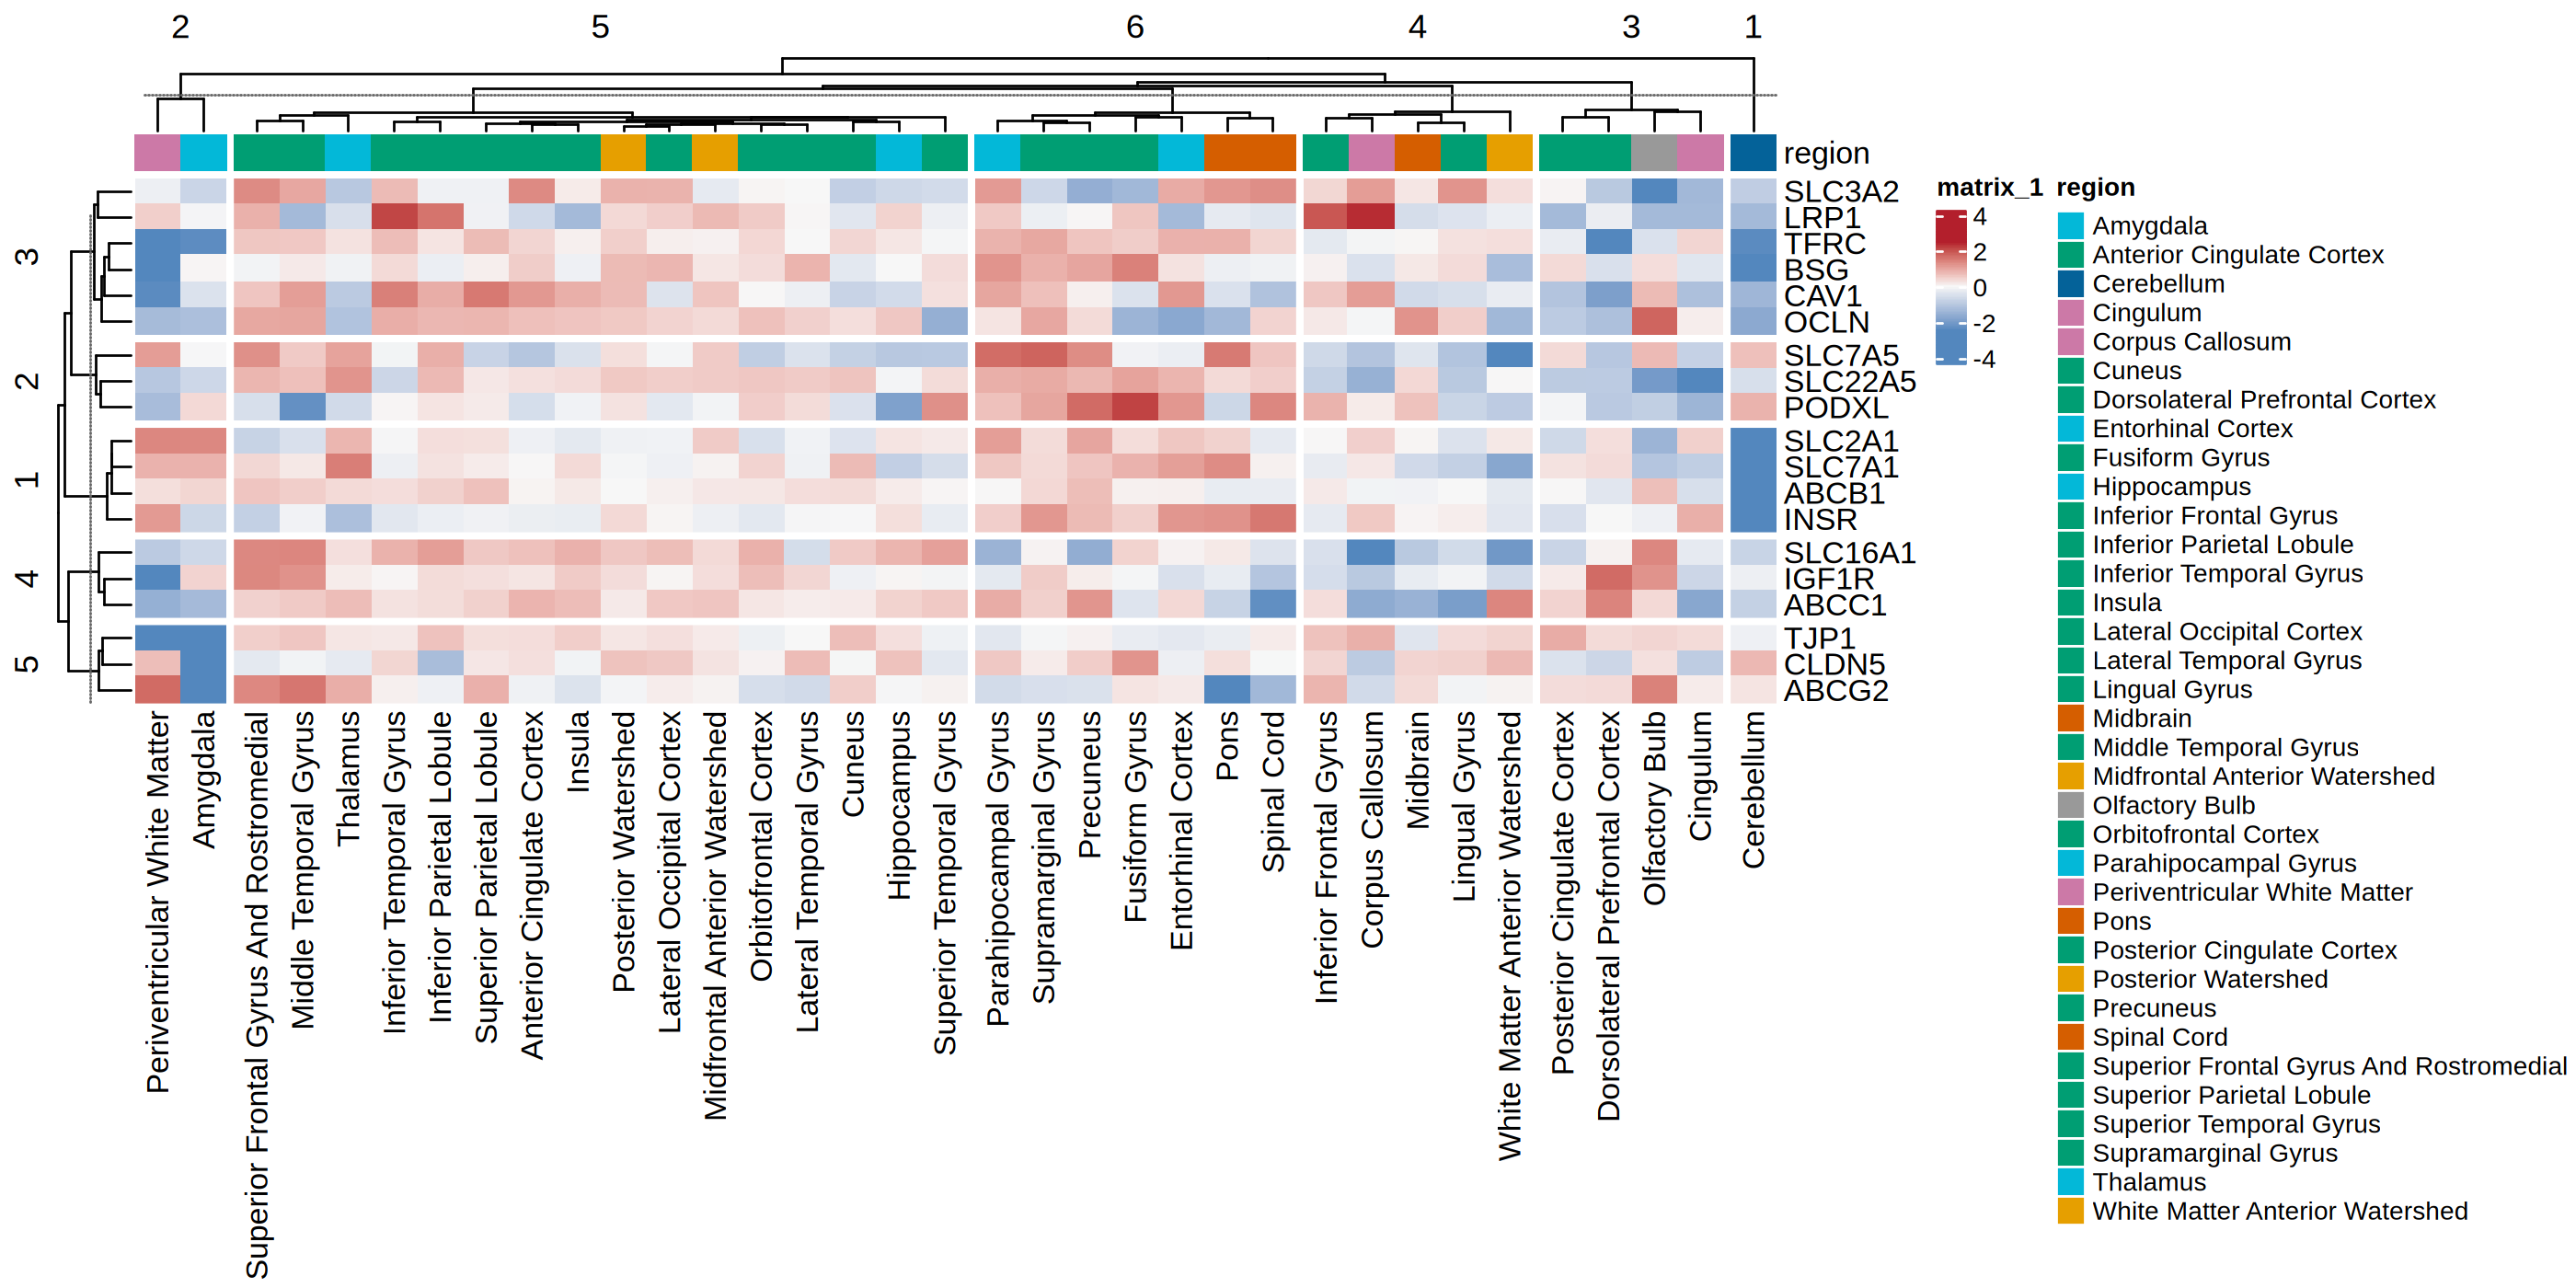

In [21]:
# Set display options (works in Jupyter or R notebooks)
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)
set.seed(42)

pdf(file = "./Results/Revision_2/Figures/Figure_5X_Capillary_BBB_signature_heatmap_per_region.pdf", width = 13, height = 7)
ht
dev.off()
ht

## Calculate the scaled and averaged expression of selected genes

In [ ]:
clean$region_name= trimws(stringr::str_to_title(clean$region_name))
clean$region_name[clean$region_name == "Mid Temporal Gyrus"] = "Middle Temporal Gyrus"
table(clean$region_name)

In [ ]:
### For capillary first
## Only focus on the genes of interest
obj = subset(clean,subset = Cell_class == "Endothelial")
genes_oi = c("ABCC1","ABCB1","ABCG2","SLC16A1","SLC2A1","SLC7A5","TFRC","INSR","IGF1R","CLDN5","OCLN","TJP1", "CAV1",'SLC7A1',"SLC22A5")

### Making sure get the corrected layer and matrix
DefaultAssay(obj) = "RNA"
obj = NormalizeData(obj)
obj <- ScaleData(obj,features = genes_oi)

mt <- AverageExpression(obj, features = genes_oi,group.by = c("region_name"),layer = "scale.data",assays = "RNA")
# # mt = AggregateExpression(
# #         obj_oi, 
# #         # features = genes_oi,
# #         group.by = c("region_name","individualID"),
# #         assays = 'RNA',
# #         slot = "counts"
# #     )
mt <- as.matrix(mt$RNA)
# ### remove the g from the colnames
# colnames(mt) <- substring(colnames(mt),2)
# colnames(mt) <- gsub("-","_",colnames(mt))

### get the neuronal density

In [ ]:
# ## Get the meta data for the clean object to calculate neuron density
# meta = clean@meta.data
# ct_oi = "Neuron"
# cell_counts = meta %>% 
#                     filter(Cell_class == ct_oi) %>%
#                     group_by(region_name,individualID) %>%
#                     summarise(cell_counts = n())

# # Also count total cells per region-sample
# total_counts <- meta %>%
#   group_by(region_name , individualID) %>%
#   summarise(total_count = n())

# cell_density = left_join(cell_counts, total_counts, by = c("region_name","individualID")) %>%
#                     mutate(cell_density = cell_counts/total_count)

# avg_density <- cell_density %>%
#   group_by(region_name) %>%
#   summarise(mean_cell_density = mean(cell_density, na.rm = TRUE)) %>%
#   arrange(factor(region_name, levels = colnames(mtx)))

# avg_density$region_name = gsub("-","_",avg_density$region_name)
# avg_density = avg_density[avg_density$region_name %in% colnames(mt),]

# # Ensure avg_density is a named vector matching the column names of mtx
# avg_vec <- avg_density$mean_cell_density
# names(avg_vec) <- avg_density$region_name
# avg_vec <- avg_vec[colnames(mt)]  # match order to matrix columns

In [ ]:
# ## Matrix with neuron density and logCPM which were calcuated above
# mtx = rbind(mt, avg_neuronal_density = avg_vec)
# mtx

### get the astrocyte density

In [ ]:
# ## Get the meta data for the clean object to calculate neuron density
# meta = clean@meta.data
# ct_oi = "Astrocyte"
# cell_counts = meta %>% 
#                     filter(Cell_class == ct_oi) %>%
#                     group_by(region_name,individualID) %>%
#                     summarise(cell_counts = n())

# # Also count total cells per region-sample
# total_counts <- meta %>%
#   group_by(region_name , individualID) %>%
#   summarise(total_count = n())

# cell_density = left_join(cell_counts, total_counts, by = c("region_name","individualID")) %>%
#                     mutate(cell_density = cell_counts/total_count)

# avg_density <- cell_density %>%
#   group_by(region_name) %>%
#   summarise(mean_cell_density = mean(cell_density, na.rm = TRUE)) %>%
#   arrange(factor(region_name, levels = colnames(mtx)))

# avg_density$region_name = gsub("-","_",avg_density$region_name)
# avg_density = avg_density[avg_density$region_name %in% colnames(mt),]

# # Ensure avg_density is a named vector matching the column names of mtx
# avg_vec <- avg_density$mean_cell_density
# names(avg_vec) <- avg_density$region_name
# avg_vec <- avg_vec[colnames(mt)]  # match order to matrix columns

In [ ]:
# ## Matrix with astrocyte density and logCPM
# mtx = rbind(mtx, avg_astrocyte_density = avg_vec)
# tail(mtx)

### Get the genes_oi for neurons

In [ ]:
### For capillary first
## Only focus on the genes of interest
obj = subset(clean,subset = Cell_class == "Neuron")
genes_oi = c("SYT1","ROBO2","NRXN1","GAD2","FOS","RBFOX3")

### Making sure get the corrected layer and matrix
DefaultAssay(obj) = "RNA"
obj = NormalizeData(obj)
obj <- ScaleData(obj,features = genes_oi)

mt <- AverageExpression(obj, features = genes_oi,group.by = c("region_name"),layer = "scale.data",assays = "RNA")
# # mt = AggregateExpression(
# #         obj_oi, 
# #         # features = genes_oi,
# #         group.by = c("region_name","individualID"),
# #         assays = 'RNA',
# #         slot = "counts"
# #     )
mt <- as.matrix(mt$RNA)
### remove the g from the colnames
# colnames(mt) <- substring(colnames(mt),2)
# colnames(mt) <- gsub("-","_",colnames(mt))

In [ ]:
combined = merge.data.frame(t(mtx), t(mt), by = "row.names", all = TRUE)
rownames(combined) = combined$Row.names
combined$Row.names = NULL
combined

### calculate the genes of interest in astrocytes

In [ ]:
### For capillary first
## Only focus on the genes of interest
obj = subset(clean,subset = Cell_class == "Astrocyte")
genes_oi = c("SLC1A2","GFAP","RFX4","NRG3","AQP4","NDRG2","ALDH1L1")

### Making sure get the corrected layer and matrix
DefaultAssay(obj) = "RNA"
obj = NormalizeData(obj)
obj <- ScaleData(obj,features = genes_oi)

mt <- AverageExpression(obj, features = genes_oi,group.by = c("region_name"),layer = "scale.data",assays = "RNA")
# # mt = AggregateExpression(
# #         obj_oi, 
# #         # features = genes_oi,
# #         group.by = c("region_name","individualID"),
# #         assays = 'RNA',
# #         slot = "counts"
# #     )
mt <- as.matrix(mt$RNA)
### remove the g from the colnames
# colnames(mt) <- substring(colnames(mt),2)
# colnames(mt) <- gsub("-","_",colnames(mt))

In [ ]:
combined = merge.data.frame(combined, t(mt), by = "row.names", all = TRUE)
rownames(combined) = combined$Row.names
combined$Row.names = NULL
combined

In [ ]:
## fill NA with 0
combined[is.na(combined)] <- 0
combined

In [ ]:
write.csv(combined, file = "./Results/Revision_2/combined_expression_density.csv", row.names = TRUE)

In [ ]:
combined = read.csv("./Results/Revision_2/Capillary_BBB_signature_and_cell_density_per_region.csv", row.names = 1)
## scale each column
combined_scaled <- as.data.frame(scale(combined))
rownames(combined_scaled) = rownames(combined)
combined_scaled

In [ ]:
# region_meta = read.csv("./Data/2_Vascular_Mapped_Region_ID.csv")
# region_meta$region_name = trimws(stringr::str_to_title(region_meta$Region_layer_1))
# region_meta
# write.csv(region_meta, "./Data/2_Vascular_Mapped_Region_ID.csv", row.names = FALSE)

In [ ]:
# ## save the combined matrix
# write.csv(combined_scaled, "./Results/Revision_2/Capillary_BBB_signature_and_cell_density_per_region_scaled.csv", row.names = TRUE)

## Calculate correlation

In [ ]:
library(DESeq2)
# Function to create pseudobulk matrix for a single cell type
CreatePseudoBulk <- function(seurat_obj, target_celltype, assay){
    seurat_sub <- subset(seurat_obj, subset = !!sym(celltype_col) == target_celltype)
    exp_mat <- AggregateExpression(object = seurat_sub,assays = assay,group.by = c("individualID","region_name"))$RNA

    # For raw counts
    keep_genes <- rowSums(exp_mat > 0) >= 5
    exp_mat <- exp_mat[keep_genes, ]
    return(exp_mat)
}

## preparing vsd matrix
CreateVSTMatrix <- function(mat= mat,var.per=0.95){
    sample_metadata = as.data.frame(colnames(mat))
    sample_metadata$individualID = str_split_fixed(sample_metadata[,1],pattern = "_",n = 2)[,1]
    sample_metadata$brain_region = str_split_fixed(sample_metadata[,1],pattern = "_",n = 2)[,2]

    dds = DESeqDataSetFromMatrix(countData = mat,
                                  colData = sample_metadata,
                                  design = ~1)
    dds = estimateSizeFactors(dds,type = "poscounts")           
    vsd = vst(dds, blind = TRUE)
    # vsd = rlog(dds, blind = TRUE)
    vst_matrix = assay(vsd)

    ## only keeping the highly variable genes
    row_var <- rowVars(vst_matrix)
    q95_var <- quantile(row_var, var.per)
    vst_matrix <- vst_matrix[row_var> q95_var, ]

    return(vst_matrix)
}

In [ ]:
## merge the layers and normalizing the data
DefaultAssay(clean) = "RNA"
clean <- NormalizeData(clean)

print(clean)

In [ ]:
# Choose the assay and slot
assay_use = "RNA"
celltype_col = "Cell_class"

ct_1 = "Endothelial"
ct_2 = "Neuron"
# ct_2 = "Astrocyte"

mat_1 = CreatePseudoBulk(seurat_obj = clean, target_celltype = ct_1, assay = "RNA")
mat_2 = CreatePseudoBulk(seurat_obj = clean, target_celltype = ct_2, assay = "RNA")

In [ ]:
# Align on common samples
common_samples <- intersect(colnames(mat_1), colnames(mat_2))
mat_1 <- mat_1[, common_samples]
mat_2 <- mat_2[, common_samples]

print(dim(mat_1))
print(dim(mat_2))

vst_mat_1 = CreateVSTMatrix(mat = mat_1,var.per = 0.5)
vst_mat_2 = CreateVSTMatrix(mat = mat_2,var.per = 0.5)

In [ ]:
vst_mat_1 = vst_mat_1[c("SLC2A1","INSR","TFRC","SLC16A1"),]
# vst_mat_2 = vst_mat_2[c("SLC1A2","GFAP","RFX4","NRG3","ALDH1L1","NDRG2"),]
vst_mat_2 = vst_mat_2[c("SYT1","ROBO2","NRXN1","GAD2","FOS","RBFOX3"),]

In [ ]:
library(Hmisc)
rownames(vst_mat_1) <- paste0(rownames(vst_mat_1), "_A")
rownames(vst_mat_2) <- paste0(rownames(vst_mat_2), "_B")

## Running the spearman correlation analysis on the two gene lists from two cell types. 
combined <- cbind(t(vst_mat_1), t(vst_mat_2))  # samples × genes

# rcorr() computes correlations and p-values
result <- rcorr(as.matrix(combined), type = "spearman")  # or "pearson"

# Extract relevant correlation block (astro × capillary only)
n_1 <- nrow(vst_mat_1)
n_2 <- nrow(vst_mat_2)

cor_mat <- result$r[1:n_1, (n_1 + 1):(n_1 + n_2)]
p_mat   <- result$P[1:n_1, (n_1 + 1):(n_1 + n_2)]

In [ ]:
# Flatten to vector
pvals <- as.vector(p_mat)

# Adjust p-values (FDR)
padj <- p.adjust(pvals, method = "bonferroni")

# Reshape to original matrix dimensions
padj_mat <- matrix(padj, nrow = nrow(p_mat), ncol = ncol(p_mat),
                   dimnames = dimnames(p_mat))

sig_pairs <- which(padj_mat < 0.05, arr.ind = TRUE)

df_long <- data.frame(
  gene_A = rep(rownames(cor_mat), times = ncol(cor_mat)),
  gene_B = rep(colnames(cor_mat), each  = nrow(cor_mat)),
  correlation = as.vector(cor_mat),
  p_value     = as.vector(p_mat),
  padj        = as.vector(padj_mat)
)


df_sig <- subset(df_long, padj < 0.05)
df_sig[order(df_sig$correlation,decreasing = T),]

In [ ]:
# Replace these with your actual gene names
gene1 <- "SLC2A1"
gene2 <- "SYT1"

rownames(vst_mat_1) = gsub("_A","",rownames(vst_mat_1))
rownames(vst_mat_2) = gsub("_B","",rownames(vst_mat_2))

# Extract expression vectors
x <- as.numeric(vst_mat_1[gene1, ])
y <- as.numeric(vst_mat_2[gene2, ])

# Optional: name the points
labels <- colnames(vst_mat_2)

df <- data.frame(
  gene1 = x,
  gene2 = y,
  region = labels
)


# Fit a linear model
model <- glm(gene2 ~ gene1, data = df, family = gaussian())
# Summary of model
summary(model)

options(repr.plot.height = 6,repr.plot.width = 7)
p = ggplot(df, aes(x = gene1, y = gene2, label = region)) +
  geom_point(color = "blue", size = 3) +
  geom_smooth(method = "lm", se = TRUE, color = "darkred") +
  # geom_text(nudge_y = 0.05, size = 3, alpha = 0.6) +  # optional labels
  labs(
    x = paste(gene1, "Expression in",ct_1),
    y = paste(gene2, "Expression in",ct_2),
    title = paste("Correlation of", gene1, "vs", gene2)
  ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    plot.title = element_text(size = 18, face = "bold"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)  # <- bezel-style outlin
  )
## Add correlation coefficient and p-value to the plot
corr = cor.test(x, y, method = "spearman")
p_value <- signif(corr$p.value, 3)
cor_coef <- round(corr$estimate, 3)
## save plot
p = p + annotate("text", x = max(x), y = max(y), label = paste("r2 =", cor_coef, "\np =", p_value), hjust = 1, vjust = 12)

## saving
# ggsave(filename = "./Results/Revision_2/Figures/Figure_5X_Capillary_BBB_signature_correlation_with_neuronal_genes.pdf", plot = p, width = 7, height = 6, device = "pdf")
p

In [ ]:
x <- as.numeric(vst_mat_1[gene1, ])
x

## test if the SLC2A1 expression in endothelial is correlated with the FDG measurements with SLC2A1 expressio.

In [ ]:
# obj_oi = subset(clean,subset = Cell_class == "Endothelial")
obj_oi = subset(clean,subset = Cell_type == "Capillary")
print(obj_oi)

In [ ]:
library(Seurat)
library(lme4)
library(emmeans)
library(dplyr)

gene_of_interest = "SLC2A1"
expr_df <- FetchData(obj_oi, vars = c(gene_of_interest, "region_abb", "individualID")) %>%
  dplyr::rename(
    vst_value = !!gene_of_interest,
    region = region_abb,
    donor = individualID
  )

# ── 2. Pseudo-bulk per donor × region (RECOMMENDED for single-cell) ───────────
# Single cells are not independent — pseudo-bulk collapses them properly
pseudobulk_df <- expr_df %>%
  group_by(region, donor) %>%
  summarise(
    mean_expr = mean(vst_value, na.rm = TRUE),
    n_cells   = n(),
    .groups   = "drop"
  )

# ── 3. Fit mixed model ────────────────────────────────────────────────────────
# donor as random effect — accounts for inter-individual variation
# only 4 donors so this is a modest random effect, but still appropriate
model <- lmer(mean_expr ~ region + (1 | donor), data = pseudobulk_df)

# # check model
# summary(model)

# ── 4. Calculate EMMs per region ──────────────────────────────────────────────
emm <- emmeans(model, ~ region)
emm_df <- as.data.frame(summary(emm))
# columns: region, emmean, SE, df, lower.CL, upper.CL

# # ── 5. Quick plot ─────────────────────────────────────────────────────────────
# library(ggplot2)

# ggplot(emm_df, aes(x = reorder(region, emmean), y = emmean)) +
#   geom_point() +
#   geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL), width = 0.3) +
#   coord_flip() +
#   labs(x = "Brain Region", y = "EMM of VST Expression",
#        title = paste("EMM expression of", gene_of_interest, "across regions")) +
#   theme_bw()
head(emm_df)

In [ ]:
## Load the FDG measurements per region
fdg_data <- read.csv("./Data/emm_regional_fdgpet_20260427.csv")
# fdg_data <- read.csv("./Data/emm_regional_fdgpet.csv")
fdg_data$scaled.mean = scale(fdg_data$emmean)
fdg_data$upper.CL - fdg_data$lower.CL
# fdg_data

rg_anno = read.csv("./Data/region.csv")

fdg_data$region_abb = rg_anno$Final_abb[match(fdg_data$region_abb, rg_anno$region_abb)]
head(fdg_data)

In [ ]:
mean_region = emm_df

library(tidyverse)

# ── Merge the two dataframes by region ──────────────────────────────────────
merged_df <- inner_join(mean_region, fdg_data, by = c("region" = "region_abb"), suffix = c("_vst", "_emm"))

#── 1. Point estimate correlation (Pearson) ──────────────────────────────────
cor_test <- cor.test(merged_df$emmean_vst, merged_df$emmean_emm, method = "pearson")
print(cor_test)

# ── 2. Spearman (robust to outliers / non-normality) ────────────────────────
cor_spearman <- cor.test(merged_df$emmean_vst, merged_df$emmean_emm, method = "spearman")
print(cor_spearman)

# ── 3. Weighted correlation (weight by inverse CI width) ────────────────────
# Narrower CI = more precise estimate = higher weight
merged_df <- merged_df %>%
  mutate(
    ci_width_vst = upper.CL_vst - lower.CL_vst,
    ci_width_emm = upper.CL_emm - lower.CL_emm,
    weight       = 1 / (ci_width_vst * ci_width_emm)  # combined precision weight
  )

library(weights)
weighted_cor <- wtd.cor(merged_df$emmean_vst, merged_df$emmean_emm, weight = merged_df$weight)
print(weighted_cor)

# # # ── 4. Bootstrap correlation with CI ─────────────────────────────────────────
# # library(boot)

# # boot_cor <- function(data, indices) {
# #   d <- data[indices, ]
# #   cor(d$mean, d$emmean, method = "pearson")
# # }

# # set.seed(42)
# # boot_result <- boot(data = merged_df, statistic = boot_cor, R = 1000)
# # boot_ci     <- boot.ci(boot_result, type = "perc")
# # print(boot_ci)

# ── 5. Scatter plot with CI error bars ───────────────────────────────────────
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(merged_df, aes(x = emmean_vst, y = emmean_emm, label = region)) +
  geom_errorbar(aes(ymin = lower.CL_emm, ymax = upper.CL_emm),
                color = "steelblue", alpha = 0.4, width = 0) +
  geom_errorbarh(aes(xmin = lower.CL_vst, xmax = upper.CL_vst),
                 color = "tomato", alpha = 0.4, height = 0) +
  geom_point(aes(size = weight), color = "blue", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  ggrepel::geom_text_repel(size = 3) +
  labs(
    title    = "Correlation: EMM Expression Mean vs EMM Mean by Brain Region in Capillary Cells",
    subtitle = paste0("Pearson r = ", round(cor_test$estimate, 3),
                      ", p = ",       round(cor_test$p.value, 4)),
    x        = "Estimated Marginal Mean (snRNA-seq)",
    y        = "Estimated Marginal Mean (FDG-PET)",
    size     = "Precision Weight"
  ) +
  theme_minimal()

# ── 6. Summary table ─────────────────────────────────────────────────────────
results_summary <- tibble(
  Method            = c("Pearson", "Spearman", "Weighted (wtd.cor)"),
  Estimate          = c(cor_test$estimate,
                        cor_spearman$estimate,
                        weighted_cor[1, "correlation"]),
  P_value           = c(cor_test$p.value,
                        cor_spearman$p.value,
                        weighted_cor[1, "p.value"])
)

print(results_summary)

## Another method

In [ ]:
## preparing vsd matrix
CreateVSTMatrix <- function(mat= mat,var.per=0.95){
    sample_metadata = as.data.frame(colnames(mat))
    sample_metadata$individualID = str_split_fixed(sample_metadata[,1],pattern = "_",n = 2)[,2]
    sample_metadata$brain_region = str_split_fixed(sample_metadata[,1],pattern = "_",n = 2)[,1]

    dds = DESeqDataSetFromMatrix(countData = mat,
                                  colData = sample_metadata,
                                  design = ~1)
    dds = estimateSizeFactors(dds,type = "poscounts")           
    vsd = vst(dds, blind = TRUE)
    # vsd = rlog(dds, blind = TRUE)
    vst_matrix = assay(vsd)

    ## only keeping the highly variable genes
    row_var <- rowVars(vst_matrix)
    q95_var <- quantile(row_var, var.per)
    vst_matrix <- vst_matrix[row_var> q95_var, ]

    return(vst_matrix)
}

In [ ]:
### Aggregation to pseudobulk 
mtx = AggregateExpression(
        obj_oi, 
        # features = gene_oi,
        group.by = c("region_abb","individualID"),
        assays = 'RNA',
        slot = "counts"
    ) 

mtx <- as.matrix(mtx$RNA)
# keep_genes <- rowSums(mtx > 0) >= 5
# mtx <- mtx[keep_genes, ]

vst_mat_1 = CreateVSTMatrix(mat = mtx,var.per = 0.5)

## Get the library size for each sample
lib_size <- Matrix::colSums(mtx)

### Get the logCPM from the matrix
cpm <- t(t(mtx) / lib_size) * 1e6
logCPM <- log2(cpm + 1)

## Only focus on the genes of interest
gene_oi = c("ABCC1","ABCB1","ABCG2","SLC16A1","SLC2A1","SLC7A5","TFRC","INSR","IGF1R","CLDN5","OCLN","TJP1", "CAV1",'SLC7A1',"SLC22A5")

logCPM = logCPM[gene_oi,]
logCPM_z <- t(scale(t(logCPM)))

### Calculate the averaged logCPM
# extract region (everything before first "_")
region <- sub("_.*$", "", colnames(logCPM))

# sanity check
table(region)

logCPM_region <- sapply(
  split(seq_len(ncol(logCPM)), region),
  function(i) {
    rowMeans(logCPM[, i, drop = FALSE])
  }
)
logCPM_region_z <- t(scale(t(logCPM_region)))

In [ ]:
### For given gene, calculate the geometric mean across samples for each region and also the lower.CL and upper.CL
gene_oi = "SLC2A1"
vst_gene = vst_mat_1[gene_oi,]
vst_gene_df = data.frame(sample = names(vst_gene), vst_value = vst_gene)
vst_gene_df$region = sub("_.*$", "", vst_gene_df$sample)
vst_gene_df$individualID = str_split_fixed(vst_gene_df$sample, pattern = "_", n = 2)[,2]

# mean_region = vst_gene_df %>%
#                 group_by(region) %>%
#                 summarise(mean_vst = mean(vst_value, na.rm = TRUE))

mean_region <- vst_gene_df %>%
  group_by(region) %>%
  summarise(
    mean_vst = mean(vst_value, na.rm = TRUE),
    se       = sd(vst_value, na.rm = TRUE) / sqrt(n()),
    n        = n(),
    lower.CL = mean_vst - qt(0.975, df = n - 1) * se,
    upper.CL = mean_vst + qt(0.975, df = n - 1) * se
  )

In [ ]:
logCPM_region_z = logCPM_region_z[,fdg_data$region_abb]
logCPM_region = logCPM_region[,fdg_data$region_abb]

In [ ]:
# Extract expression vectors
x <- as.numeric(logCPM_region["SLC2A1", ])
y <- as.numeric(fdg_data[,"scaled.mean"])

# Optional: name the points
labels <- colnames(logCPM_region)

df <- data.frame(
  gene1 = x,
  gene2 = y,
  region = labels
)


# Fit a linear model
model <- glm(gene2 ~ gene1, data = df, family = gaussian())
# Summary of model
summary(model)

options(repr.plot.height = 6,repr.plot.width = 7)
p = ggplot(df, aes(x = x, y = y, label = region)) +
  geom_point(color = "blue", size = 3) +
  geom_smooth(method = "lm", se = TRUE, color = "darkred") +
  # geom_text(nudge_y = 0.05, size = 3, alpha = 0.6) +  # optional labels
  # labs(
  #   x = paste(x, "Expression in",ct_1),
  #   y = paste(y, "Expression in",ct_2),
  #   title = paste("Correlation of", gene1, "vs", y)
  # ) +
  theme_minimal() +
  theme(
    axis.title = element_text(size = 16),
    axis.text = element_text(size = 14),
    plot.title = element_text(size = 18, face = "bold"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)  # <- bezel-style outlin
  )
## Add correlation coefficient and p-value to the plot
corr = cor.test(x, y, method = "pearson")
p_value <- signif(corr$p.value, 3)
cor_coef <- round(corr$estimate, 3)
## save plot
p = p + annotate("text", x = max(x), y = max(y), label = paste("r2 =", cor_coef, "\np =", p_value), hjust = 1, vjust = 12)

## saving
# ggsave(filename = "./Results/Revision_2/Figures/Figure_5X_Capillary_BBB_signature_correlation_with_neuronal_genes.pdf", plot = p, width = 7, height = 6, device = "pdf")
p

In [ ]:

# mean_region

In [ ]:
mean_region = emm_df
# mean_region


In [ ]:
# # obj_oi = subset(clean,subsaet = Cell_class == "Endothelial")
# obj_oi = subset(clean,subset = Cell_type == "Capillary")

In [ ]:
# ### Making sure get the corrected layer and matrix
# DefaultAssay(obj_oi) = "RNA"
# # obj_oi = JoinLayers(obj_oi)

# ### Aggregation to pseudobulk 
# mtx = AggregateExpression(
#         obj_oi, 
#         # features = gene_oi,
#         group.by = c("region_abb","individualID"),
#         assays = 'RNA',
#         slot = "counts"
#     ) 
# mtx <- as.matrix(mtx$RNA)

# ## Get the library size for each sample
# lib_size <- Matrix::colSums(mtx)

# ### Get the logCPM from the matrix
# cpm <- t(t(mtx) / lib_size) * 1e6
# logCPM <- log2(cpm + 1)

# ## Only focus on the genes of interest
# gene_oi = c("ABCC1","ABCB1","ABCG2","SLC16A1","SLC2A1","SLC7A5","TFRC","INSR","IGF1R","CLDN5","OCLN","TJP1", "CAV1",'SLC7A1',"SLC22A5")

# logCPM = logCPM[gene_oi,]
# logCPM_z <- t(scale(t(logCPM)))

# ### Calculate the averaged logCPM
# # extract region (everything before first "_")
# region <- sub("_.*$", "", colnames(logCPM))

# # sanity check
# table(region)

# logCPM_region <- sapply(
#   split(seq_len(ncol(logCPM)), region),
#   function(i) {
#     rowMeans(logCPM[, i, drop = FALSE])
#   }
# )
# logCPM_region_z <- t(scale(t(logCPM_region)))

In [ ]:
as.numeric(logCPM_region["SLC2A1", ])

## Calculating module score for gene modules and check their correlation with MRI measurements.

In [ ]:
# 1. Read the module table
modules_df <- read.csv("./Data/Modules_for_MRI_correlation_expanded.csv", stringsAsFactors = FALSE)

# 2. Build a named list: one character vector of genes per module
module_list <- split(modules_df$Gene_symbol, modules_df$Module_name)

# print(module_list)

In [98]:
names(module_list)

[1] "Astrocyte_neurovascular_coupling"               
 [2] "EC_NO_production_conservative"                  
 [3] "EC_vasodilatory_relaxation_expanded"            
 [4] "Endothelial_neurovascular_coupling"             
 [5] "Mechanosensitive_flow_responsive"               
 [6] "Mural_contractility_smooth_muscle_tone_expanded"
 [7] "Mural_pericyte_neurovascular_response"          
 [8] "Neuronal_activity_upstream_demand"              
 [9] "NO_cGMP_response_mural_weighted"                
[10] "Prostaglandin_prostacyclin_response_optional"   
[11] "Vasoconstrictive_signaling_expanded"

In [82]:
# Quick sanity check — see how many genes per module and which are present in your object
for (m in names(module_list)) {
  genes  <- module_list[[m]]
  found  <- intersect(genes, rownames(clean))
  cat(sprintf("%s: %d/%d genes found in 'clean'\n",
              m, length(found), length(genes)))
}

Astrocyte_neurovascular_coupling: 17/17 genes found in 'clean'
EC_NO_production_conservative: 20/20 genes found in 'clean'
EC_vasodilatory_relaxation_expanded: 24/24 genes found in 'clean'
Endothelial_neurovascular_coupling: 13/13 genes found in 'clean'
Mechanosensitive_flow_responsive: 10/10 genes found in 'clean'
Mural_contractility_smooth_muscle_tone_expanded: 18/18 genes found in 'clean'
Mural_pericyte_neurovascular_response: 15/15 genes found in 'clean'
Neuronal_activity_upstream_demand: 10/10 genes found in 'clean'
NO_cGMP_response_mural_weighted: 8/8 genes found in 'clean'
Prostaglandin_prostacyclin_response_optional: 3/3 genes found in 'clean'
Vasoconstrictive_signaling_expanded: 11/12 genes found in 'clean'


In [83]:
# 3. Add module scores to the Seurat object
#    Seurat appends a number (1, 2, ...) to the `name` argument, so we loop
#    one module at a time and supply a clean name for each.
for (m in names(module_list)) {
  genes <- intersect(module_list[[m]], rownames(clean))
  clean <- AddModuleScore(
    object   = clean,
    features = list(genes),
    name     = m,        # Seurat will create column: <m>1
    ctrl     = 100,      # default; reduce if any module has very few genes
    seed     = 42
  )
}

In [84]:
# 4. Rename the columns to drop the trailing "1" Seurat appends
for (m in names(module_list)) {
  old <- paste0(m, "1")
  if (old %in% colnames(clean@meta.data)) {
    colnames(clean@meta.data)[colnames(clean@meta.data) == old] <- m
  }
}

# 5. Verify
head(clean@meta.data[, names(module_list)])

,Astrocyte_neurovascular_coupling,EC_NO_production_conservative,EC_vasodilatory_relaxation_expanded,Endothelial_neurovascular_coupling,Mechanosensitive_flow_responsive,Mural_contractility_smooth_muscle_tone_expanded,Mural_pericyte_neurovascular_response,Neuronal_activity_upstream_demand,NO_cGMP_response_mural_weighted,Prostaglandin_prostacyclin_response_optional,Vasoconstrictive_signaling_expanded
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,0.11056974,-0.05876125,-0.01976794,-0.04392971,-0.02289282,-0.1108392,-0.1478817,-0.02647658,-0.1407307,-0.013333333,-0.009372071
1,0.03318159,-0.12681313,-0.05027933,0.05640206,0.12819979,-0.4174370,-0.2388489,0.50325866,-0.3870095,-0.003333333,-0.011246485
2,0.75336084,-0.57477501,-0.09672683,-0.23728189,-0.04547347,-1.1769077,-0.6065548,-0.27678208,-1.7212449,0.303333333,-0.089034677
3,0.91190696,-0.09745897,0.07643962,-0.14616613,-0.06763788,-0.0187602,-0.2404476,-0.07535642,-0.2511840,-0.003333333,-0.013120900
4,0.05633402,1.47289571,0.18983670,2.20650037,0.22507804,-0.5202103,-0.5219824,0.01038697,-0.5074425,-0.003333333,-0.017806935
5,0.08250942,-0.24139756,-0.04512248,-0.15654952,-0.08324662,-0.2080841,-0.2808953,0.08492872,-0.5399188,-0.016666667,-0.023430178


### test if the module score correlates with the MRI measurement across regions

In [67]:
suppressPackageStartupMessages({
    library(lme4)
    library(emmeans)
    library(dplyr)
    library(tidyverse)
    library(weights)
})

In [124]:
# ── 0. Subset to endothelial cells ────────────────────────────────────────────
obj_oi <- subset(clean, subset = Cell_class == "Endothelial")
print(obj_oi)

An object of class Seurat 
36782 features across 45554 samples within 1 assay 
Active assay: RNA (36782 features, 0 variable features)
 2 layers present: counts, data
 8 dimensional reductions calculated: Xharmony_, Xpca_, Xpcaharmony_, Xumap.decontx_, Xumap.harmony_, Xumap.harmony.denoised_, Xumap.rna_, umapharmony_


In [ ]:
# ── 1. Pick which module score and which MRI metric to correlate ──────────────
# module_of_interest <- "Endothelial_NO_production_MRI_ready"
# module_of_interest = "Endothelial_vasodilatory_signaling_MRI_ready"
module_of_interest = "Mechanosensitive_flow_responsive"
module_of_interest = "Endothelial_vasodilatory_signaling_MRI_ready"
module_of_interest = "EC_NO_production_conservative"
module_of_interest = "Endothelial_neurovascular_coupling"

mri_metric <- "CBF"       # "ATT", "CBF", or "kw"

# ── 2. Pull the module score + grouping vars from the Seurat object ──────────
# AddModuleScore stored the score in meta.data under <module_of_interest>
stopifnot(module_of_interest %in% colnames(obj_oi@meta.data))

score_df <- FetchData(
  obj_oi,
  vars = c(module_of_interest, "region_abb", "individualID")
) %>%
  dplyr::rename(
    score  = !!module_of_interest,
    region = region_abb,
    donor  = individualID
  )

# ── 3. Pseudo-bulk per donor × region ────────────────────────────────────────
pseudobulk_df <- score_df %>%
  group_by(region, donor) %>%
  summarise(
    mean_score = mean(score, na.rm = TRUE),
    n_cells    = n(),
    .groups    = "drop"
  )

# ── 4. Mixed model: region as fixed, donor as random ─────────────────────────
model  <- lmer(mean_score ~ region + (1 | donor), data = pseudobulk_df)
emm    <- emmeans(model, ~ region)
emm_df <- as.data.frame(summary(emm))
head(emm_df)

,region,emmean,SE,df,lower.CL,upper.CL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ACA,0.3094477,0.1911283,31.71293,-0.080006216,0.6989016
2,ACC,0.4760317,0.1515848,14.44869,0.151859319,0.8002042
3,AMY,0.3688883,0.1515848,14.44869,0.044715921,0.6930608
4,BA,0.3543949,0.1911283,31.71293,-0.035058986,0.7438489
5,CB,0.7462699,0.1515848,14.44869,0.422097492,1.0704423
6,CC,0.3517028,0.1658861,19.92647,0.005588607,0.6978169


In [161]:
# ── 5. Load MRI data and keep only the chosen metric ─────────────────────────
mri_df_all <- read.csv("./Data/Brain_flow/emm_regional_gm.csv")
mri_df <- mri_df_all[mri_df_all$metric == mri_metric, ]

# Apply the same region-name harmonization you used for FDG
rg_anno <- read.csv("./Data/region.csv")
mri_df$region_abb <- rg_anno$Final_abb[match(mri_df$region_abb, rg_anno$region_abb)]

# ── 6. Merge by region ───────────────────────────────────────────────────────
merged_df <- inner_join(
  emm_df, mri_df,
  by = c("region" = "region_abb"),
  suffix = c("_score", "_mri")
)

region,emmean_score,SE_score,df_score,lower.CL_score,upper.CL_score,metric,endo_clusters,emmean_mri,SE_mri,df_mri,lower.CL_mri,upper.CL_mri
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACC,0.4760317,0.1515848,14.44869,0.15185932,0.8002042,CBF,C3,60.88593,4.373215,88.59405,52.19590,69.57596
AMY,0.3688883,0.1515848,14.44869,0.04471592,0.6930608,CBF,C3,43.38247,4.373215,88.59405,34.69244,52.07250
CB,0.7462699,0.1515848,14.44869,0.42209749,1.0704423,CBF,C1,29.72486,4.373215,88.59405,21.03483,38.41489
CUN,0.5793150,0.1515848,14.44869,0.25514254,0.9034874,CBF,C1,48.10522,4.373215,88.59405,39.41518,56.79525
DLPFC,0.5695338,0.1515848,14.44869,0.24536139,0.8937062,CBF,C3,51.14423,4.373215,88.59405,42.45420,59.83426
EC,0.6326006,0.1658861,19.92647,0.28648647,0.9787148,CBF,C1,49.02334,4.373215,88.59405,40.33331,57.71338
FG,0.5045690,0.1658861,19.92647,0.15845486,0.8506832,CBF,C2,46.14237,4.373215,88.59405,37.45234,54.83240
HIP,0.4410859,0.1515848,14.44869,0.11691350,0.7652583,CBF,C2,42.60152,4.373215,88.59405,33.91148,51.29155
IFG,0.5057658,0.1515848,14.44869,0.18159339,0.8299382,CBF,C2,66.92820,4.373215,88.59405,58.23817,75.61824


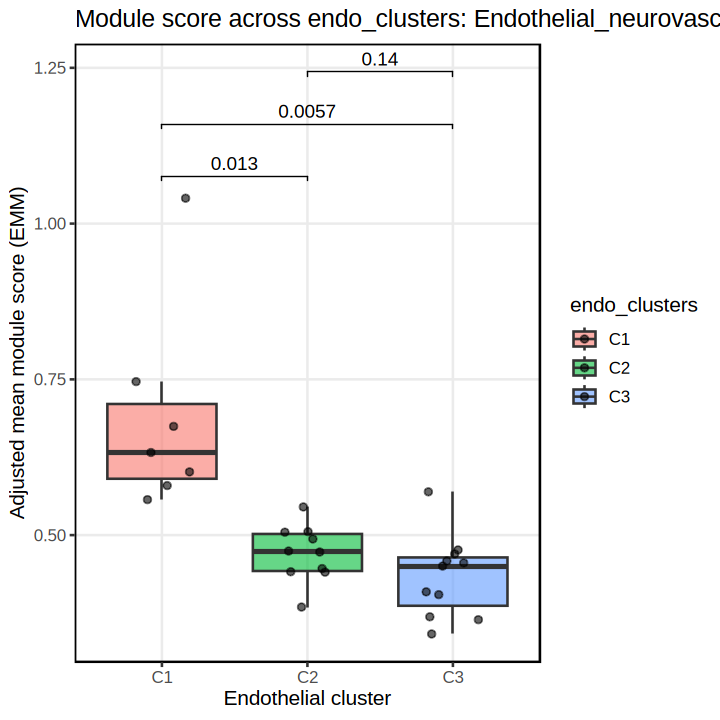

In [162]:
## merged_df
merged_df
my_comparisons <- list(c("C1", "C2"), c("C1", "C3"), c("C2", "C3"))

options(repr.plot.width = 6, repr.plot.height = 6)
ggplot(merged_df, aes(x = endo_clusters, y = emmean_score, fill = endo_clusters)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.6) +
  geom_jitter(width = 0.2, alpha = 0.6, size = 1.5) +
  stat_compare_means(
    comparisons = my_comparisons,
    method      = "t.test",
    label       = "p.format",
    tip.length  = 0.01
  ) +
  labs(
    title = paste("Module score across endo_clusters:", module_of_interest),
    x     = "Endothelial cluster",
    y     = "Adjusted mean module score (EMM)"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.border     = element_rect(color = "black", fill = NA, linewidth = 0.8),
    panel.grid.minor = element_blank()
  )

In [156]:
# ── 7. Correlations ──────────────────────────────────────────────────────────
cor_test     <- cor.test(merged_df$emmean_score, merged_df$emmean_mri, method = "pearson")
cor_spearman <- cor.test(merged_df$emmean_score, merged_df$emmean_mri, method = "spearman")
print(cor_test); print(cor_spearman)

# Weighted by inverse CI width (precision)
merged_df <- merged_df %>%
  mutate(
    ci_width_score = upper.CL_score - lower.CL_score,
    ci_width_mri   = upper.CL_mri   - lower.CL_mri,
    weight         = 1 / (ci_width_score * ci_width_mri)
  )

weighted_cor <- wtd.cor(merged_df$emmean_score, merged_df$emmean_mri,
                        weight = merged_df$weight)
print(weighted_cor)


	Pearson's product-moment correlation

data:  merged_df$emmean_score and merged_df$emmean_mri
t = -2.2428, df = 26, p-value = 0.03366
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.67439461 -0.03476078
sample estimates:
       cor 
-0.4026164 


	Spearman's rank correlation rho

data:  merged_df$emmean_score and merged_df$emmean_mri
S = 5066, p-value = 0.04309
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.3864258 

  correlation   std.err   t.value    p.value
Y  -0.4041944 0.1793822 -2.253258 0.03290314


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”
`height` was translated to `width`.


# A tibble: 3 × 3
  Method             Estimate P_value
  <chr>                 <dbl>   <dbl>
1 Pearson              -0.353  0.0657
2 Spearman             -0.356  0.0634
3 Weighted (wtd.cor)   -0.364  0.0569


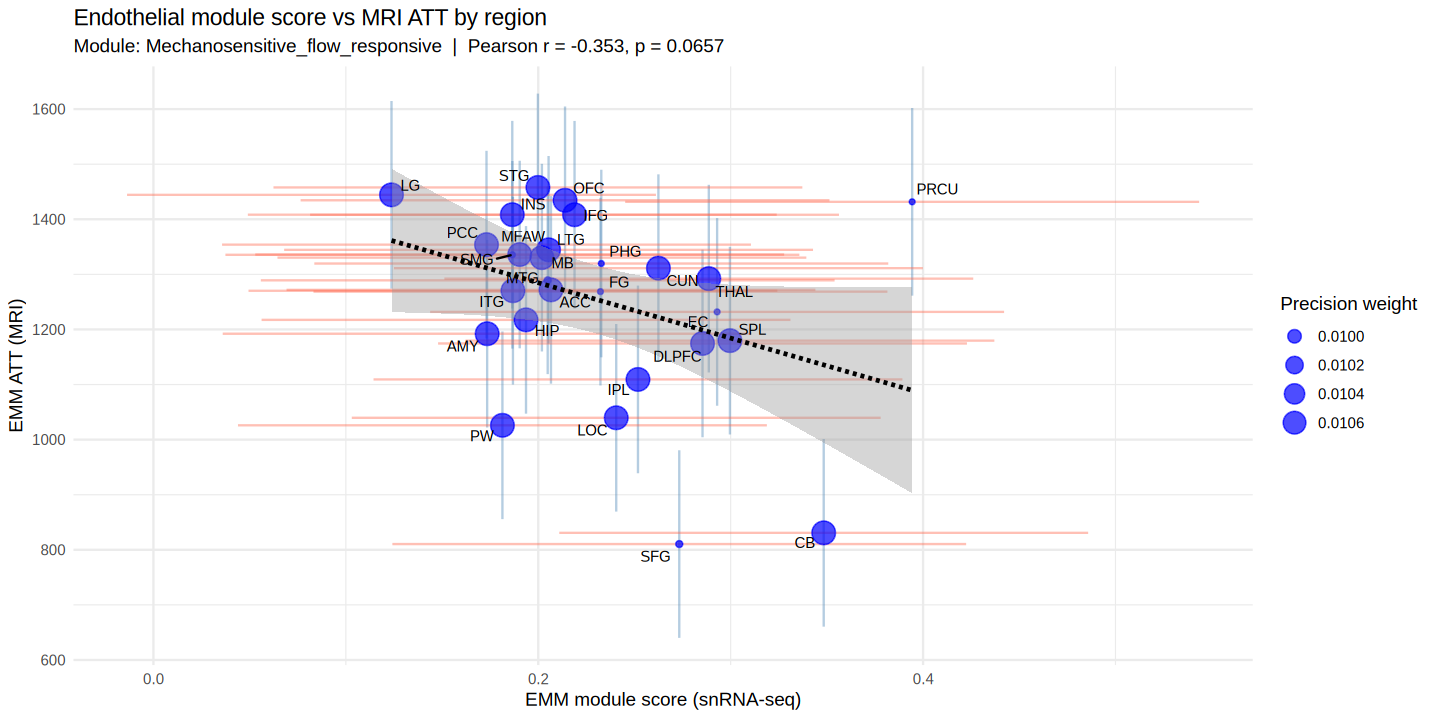

In [145]:
# ── 8. Scatter plot ──────────────────────────────────────────────────────────
options(repr.plot.width = 12, repr.plot.height = 6)
ggplot(merged_df, aes(x = emmean_score, y = emmean_mri, label = region)) +
  geom_errorbar(aes(ymin = lower.CL_mri, ymax = upper.CL_mri),
                color = "steelblue", alpha = 0.4, width = 0) +
  geom_errorbarh(aes(xmin = lower.CL_score, xmax = upper.CL_score),
                 color = "tomato", alpha = 0.4, height = 0) +
  geom_point(aes(size = weight), color = "blue", alpha = 0.7) +
  geom_smooth(method = "lm", se = TRUE, color = "black", linetype = "dashed") +
  ggrepel::geom_text_repel(size = 3) +
  labs(
    title    = paste0("Endothelial module score vs MRI ", mri_metric, " by region"),
    subtitle = paste0("Module: ", module_of_interest,
                      "  |  Pearson r = ", round(cor_test$estimate, 3),
                      ", p = ", round(cor_test$p.value, 4)),
    x        = "EMM module score (snRNA-seq)",
    y        = paste0("EMM ", mri_metric, " (MRI)"),
    size     = "Precision weight"
  ) +
  theme_minimal()

# ── 9. Summary ───────────────────────────────────────────────────────────────
results_summary <- tibble(
  Method   = c("Pearson", "Spearman", "Weighted (wtd.cor)"),
  Estimate = c(cor_test$estimate, cor_spearman$estimate,
               weighted_cor[1, "correlation"]),
  P_value  = c(cor_test$p.value, cor_spearman$p.value,
               weighted_cor[1, "p.value"])
)
print(results_summary)

In [129]:
modules <- c("Endothelial_NO_production_MRI_ready",
             "Endothelial_vasodilatory_signaling_MRI_ready",
             "Mural_contractility_vascular_tone_MRI_ready",
             names(module_list))
metrics <- c("ATT", "CBF", "kw")

all_results <- list()

for (mod in modules) {
  score_df <- FetchData(obj_oi, vars = c(mod, "region_abb", "individualID")) %>%
    dplyr::rename(score = !!mod, region = region_abb, donor = individualID)

  pb <- score_df %>%
    group_by(region, donor) %>%
    summarise(mean_score = mean(score, na.rm = TRUE), .groups = "drop")

  emm_df <- as.data.frame(summary(
    emmeans(lmer(mean_score ~ region + (1 | donor), data = pb), ~ region)
  ))

  for (met in metrics) {
    mri_sub <- mri_df_all[mri_df_all$metric == met, ]
    mri_sub$region_abb <- rg_anno$Final_abb[match(mri_sub$region_abb, rg_anno$region_abb)]

    merged <- inner_join(emm_df, mri_sub, by = c("region" = "region_abb"),
                         suffix = c("_score", "_mri"))
    if (nrow(merged) < 3) next

    ct <- cor.test(merged$emmean_score, merged$emmean_mri)
    all_results[[paste(mod, met, sep = "__")]] <- tibble(
      module = mod, metric = met,
      pearson_r = ct$estimate, p = ct$p.value, n_regions = nrow(merged)
    )
  }
}

res = bind_rows(all_results) %>% arrange(p)

In [139]:
res

module,metric,pearson_r,p,n_regions
<chr>,<chr>,<dbl>,<dbl>,<int>
Vasoconstrictive_signaling_expanded,ATT,-0.544533372,0.002736246,28
Mechanosensitive_flow_responsive,CBF,-0.418705603,0.026583002,28
Vasoconstrictive_signaling_expanded,kw,-0.409323016,0.030544213,28
Endothelial_vasodilatory_signaling_MRI_ready,CBF,-0.402616396,0.033657710,28
Mechanosensitive_flow_responsive,kw,-0.377357524,0.047744926,28
EC_NO_production_conservative,CBF,-0.356085364,0.062912268,28
Mechanosensitive_flow_responsive,ATT,-0.352652955,0.065676149,28
Vasoconstrictive_signaling_expanded,CBF,-0.342458593,0.074442067,28
Endothelial_neurovascular_coupling,kw,-0.331990084,0.084352313,28


In [112]:
write.csv(res, "./Results/Revision_2/Giuseppe/Endothelial_module_MRI_correlation_summary.csv", row.names = FALSE)

## Draw facet plots on module of interst across the three region clustters

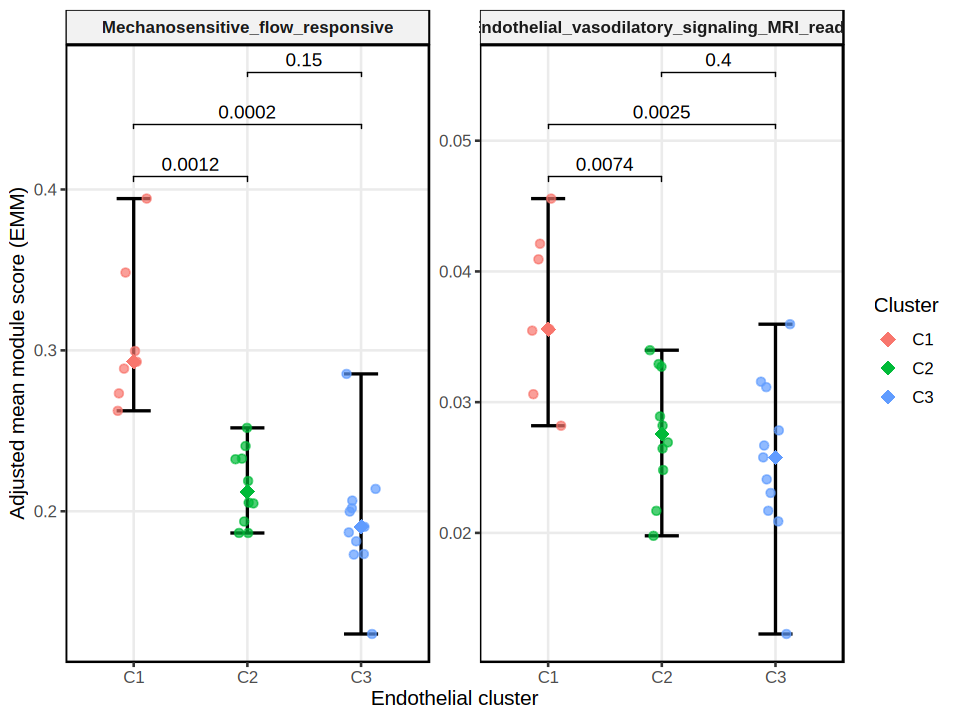

In [196]:
library(Seurat)
library(lme4)
library(emmeans)
library(dplyr)
library(tidyr)
library(purrr)
library(ggplot2)
library(ggpubr)

modules_to_plot <- c(
  # "Vasoconstrictive_signaling_expanded",
  "Mechanosensitive_flow_responsive",
  "Endothelial_vasodilatory_signaling_MRI_ready"
  # "EC_NO_production_conservative",
  # "Endothelial_neurovascular_coupling"
)
mri_df_full  = read.csv("./Data/Brain_flow/emm_regional_gm.csv")
# ── 1. Build region → endo_clusters lookup once (from your MRI table) ────────
# Use any one metric since cluster assignment is per-region, not per-metric
cluster_lookup <- mri_df_full %>%
  filter(metric == "CBF") %>%                   # any metric works
  distinct(region_abb, endo_clusters) %>%
  mutate(region_abb = rg_anno$Final_abb[match(region_abb, rg_anno$region_abb)])

# ── 2. Loop modules → fit lmer → extract EMMs → tag with cluster ─────────────
emm_long <- map_dfr(modules_to_plot, function(mod) {

  score_df <- FetchData(obj_oi, vars = c(mod, "region_abb", "individualID")) %>%
    dplyr::rename(score = !!mod, region = region_abb, donor = individualID)

  pb <- score_df %>%
    group_by(region, donor) %>%
    summarise(mean_score = mean(score, na.rm = TRUE), .groups = "drop")

  emm_df <- as.data.frame(summary(
    emmeans(lmer(mean_score ~ region + (1 | donor), data = pb), ~ region)
  ))

  emm_df %>%
    left_join(cluster_lookup, by = c("region" = "region_abb")) %>%
    filter(!is.na(endo_clusters)) %>%
    mutate(module = mod)
})

# Optional: control facet order to match your interest order
emm_long$module <- factor(emm_long$module, levels = modules_to_plot)

# ── 3. Plot ──────────────────────────────────────────────────────────────────
my_comparisons <- list(c("C1", "C2"), c("C1", "C3"), c("C2", "C3"))

# options(repr.plot.width = 14, repr.plot.height = 6)
# ggplot(emm_long, aes(x = endo_clusters, y = emmean, fill = endo_clusters)) +
#   geom_boxplot(outlier.shape = NA, alpha = 0.6) +
#   geom_jitter(width = 0.2, alpha = 0.6, size = 1.5) +
#   facet_wrap(~ module, scales = "free_y", nrow = 1) +
#   stat_compare_means(
#     comparisons = my_comparisons,
#     method      = "t.test",
#     label       = "p.format",
#     tip.length  = 0.01
#   ) +
#   labs(
#     x    = "Endothelial cluster",
#     y    = "Adjusted mean module score (EMM)",
#     fill = "Cluster"
#   ) +
#   theme_bw(base_size = 12) +
#   theme(
#     panel.border     = element_rect(color = "black", fill = NA, linewidth = 0.8),
#     panel.grid.minor = element_blank(),
#     strip.background = element_rect(fill = "grey95", color = "black"),
#     strip.text       = element_text(size = 10, face = "bold")
#   )
options(repr.plot.width = 8, repr.plot.height = 6)
ggplot(emm_long, aes(x = endo_clusters, y = emmean)) +
  # black whiskers: min to max
  stat_summary(
    fun.min   = min, fun.max = max,
    geom      = "errorbar",
    width     = 0.3,
    linewidth = 0.7,
    color     = "black"
  ) +
  # median dot — colored by cluster
  stat_summary(
    aes(color = endo_clusters),
    fun   = median,
    geom  = "point",
    size  = 4,
    shape = 18
  ) +
  # individual region points — colored by cluster
  geom_jitter(aes(color = endo_clusters),
              width = 0.15, alpha = 0.7, size = 1.8) +
  facet_wrap(~ module, scales = "free_y", nrow = 1) +
  stat_compare_means(
    comparisons = my_comparisons,
    method      = "t.test",
    label       = "p.format",
    tip.length  = 0.01,
    color       = "black"
  ) +
  labs(
    x     = "Endothelial cluster",
    y     = "Adjusted mean module score (EMM)",
    color = "Cluster"
  ) +
  theme_bw(base_size = 12) +
  theme(
    panel.border     = element_rect(color = "black", fill = NA, linewidth = 0.8),
    panel.grid.minor = element_blank(),
    strip.background = element_rect(fill = "grey95", color = "black"),
    strip.text       = element_text(size = 10, face = "bold")
  )

In [172]:
write.csv(emm_long, "./Results/Revision_2/Giuseppe/endo_cluster_module_emm_scores.csv", row.names = FALSE)

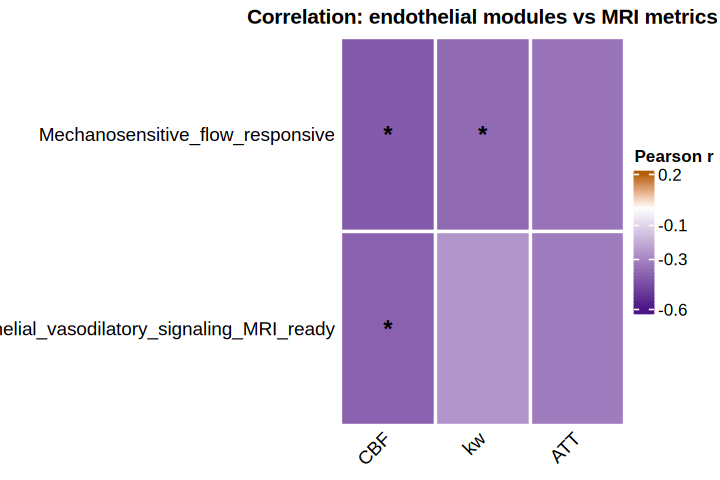

In [191]:
library(ComplexHeatmap)
library(circlize)
library(dplyr)
library(tidyr)

# ── 1. Subset and reshape to wide matrix ─────────────────────────────────────
modules_to_plot <- c(
  # "Vasoconstrictive_signaling_expanded",
  "Mechanosensitive_flow_responsive",
  "Endothelial_vasodilatory_signaling_MRI_ready"
)

res <- read.csv("./Results/Revision_2/Giuseppe/Endothelial_module_MRI_correlation_summary.csv")

res_subset <- res %>%
  filter(module %in% modules_to_plot) %>%
  mutate(module = factor(module, levels = modules_to_plot))

# Correlation matrix: rows = modules, cols = metrics
mat_r <- res_subset %>%
  select(module, metric, pearson_r) %>%
  pivot_wider(names_from = metric, values_from = pearson_r) %>%
  column_to_rownames("module") %>%
  as.matrix()

# Matching p-value matrix in the same shape
mat_p <- res_subset %>%
  select(module, metric, p) %>%
  pivot_wider(names_from = metric, values_from = p) %>%
  column_to_rownames("module") %>%
  as.matrix()
mat_p <- mat_p[rownames(mat_r), colnames(mat_r)]   # ensure alignment

# ── 2. Significance asterisks ────────────────────────────────────────────────
sig_label <- function(p) {
  ifelse(is.na(p), "",
  ifelse(p < 0.001, "***",
  ifelse(p < 0.01,  "**",
  ifelse(p < 0.05,  "*", ""))))
}
mat_sig <- matrix(sig_label(mat_p), nrow = nrow(mat_p),
                  dimnames = dimnames(mat_p))

# ── 3. Color: white → purple, diverging through white at 0 ──────────────────
# Negative correlations dominate your data, so anchor the scale to actual range
col_fun <- colorRamp2(
  c(-0.6, 0, 0.2),
  c("#4A1486", "white", "#B45F06")   # deep purple → white → warm accent
)
# If you'd rather have a single-hue (purple) sequential ramp showing |r|:
# col_fun <- colorRamp2(c(0, 0.3, 0.6), c("white", "#BCBDDC", "#54278F"))
# and feed abs(mat_r) instead of mat_r — but you'd lose sign info.

# ── 4. Draw the heatmap ──────────────────────────────────────────────────────
options(repr.plot.width = 6, repr.plot.height = 4)

ht <- Heatmap(
  mat_r,
  name            = "Pearson r",
  col             = col_fun,
  rect_gp         = gpar(col = "white", lwd = 2),
  cluster_rows    = FALSE,
  cluster_columns = FALSE,
  row_names_side  = "left",
  column_names_side = "bottom",
  column_names_rot  = 45,
  row_names_gp    = gpar(fontsize = 11),
  column_names_gp = gpar(fontsize = 11),
  cell_fun = function(j, i, x, y, width, height, fill) {
    grid.text(mat_sig[i, j], x, y,
              gp = gpar(fontsize = 14, fontface = "bold",
                        col = ifelse(abs(mat_r[i, j]) > 0.45, "white", "black")))
  },
  heatmap_legend_param = list(
    title = "Pearson r",
    at = c(-0.6, -0.3, -0.1, 0.2),
    legend_height = unit(3, "cm")
  ),
  column_title = "Correlation: endothelial modules vs MRI metrics",
  column_title_gp = gpar(fontsize = 12, fontface = "bold")
)

draw(ht, padding = unit(c(2, 10, 2, 2), "mm"))

In [183]:
unique(res$module)

[1] "Vasoconstrictive_signaling_expanded"            
 [2] "Mechanosensitive_flow_responsive"               
 [3] "Endothelial_vasodilatory_signaling_MRI_ready"   
 [4] "EC_NO_production_conservative"                  
 [5] "Endothelial_neurovascular_coupling"             
 [6] "EC_vasodilatory_relaxation_expanded"            
 [7] "Endothelial_NO_production_MRI_ready"            
 [8] "Prostaglandin_prostacyclin_response_optional"   
 [9] "Astrocyte_neurovascular_coupling"               
[10] "Mural_pericyte_neurovascular_response"          
[11] "Neuronal_activity_upstream_demand"              
[12] "NO_cGMP_response_mural_weighted"                
[13] "Mural_contractility_vascular_tone_MRI_ready"    
[14] "Mural_contractility_smooth_muscle_tone_expanded"

In [197]:
# ## plottitng the correlation between the module score and the MRI metric as a heatmap for selected modules
# # modules_to_plot <- c(
# #   "Vasoconstrictive_signaling_expanded",
# #   "Mechanosensitive_flow_responsive",
# #   "Endothelial_vasodilatory_signaling_MRI_ready",
# #   "EC_NO_production_conservative",
# #   "Endothelial_neurovascular_coupling"
# # )

# ## highlight the results with sifgnificant correlation (p < 0.05) in the heatmap

# ## correlation results for all the modules and all the MRI metrics
# res = read.csv("./Results/Revision_2/Giuseppe/Endothelial_module_MRI_correlation_summary.csv")
# # res_subset = res %>% filter(module %in% modules_to_plot)
# res_subset = res
# modules_to_plot = unique(res_subset$module)
# res_subset$module = factor(res_subset$module, levels = modules_to_plot) 
# options(repr.plot.width = 8, repr.plot.height = 6)
# ggplot(res_subset, aes(x = metric, y = module, fill = pearson_r)) +
#   geom_tile(color = "white") +
#   scale_fill_gradient2(
#     low = "blue", mid = "white", high = "red",
#     midpoint = -0, limits = c(-0.6, 0.5),
#     name = "Pearson r"
#   ) +
#   geom_text(aes(label = paste0("r=", round(pearson_r, 2), "\np=", signif(p, 2))),
#             color = "black", size = 3) +
#   labs(
#     title = "Correlation of Endothelial Module Scores with MRI Metrics",
#     x     = "MRI Metric",
#     y     = "Endothelial bModule"
#   ) +
#   theme_minimal() +
#   theme(
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     panel.grid = element_blank(),
#     panel.border = element_rect(color = "black", fill = NA, linewidth = 0.8)
#   ) 